In [1]:
import pandas as pd
from tabulate import tabulate
from utils import PREPROCESSING_CONFIGS, VECTORIZER_CONFIGS
import matplotlib.pyplot as plt
import seaborn as sns
from utils import TextPreprocessor, Word2VecVectorizer
from utils import RAW_DATA_DIR, OUTPUT_DATA_DIR
from wordcloud import WordCloud
import numpy as np
df = pd.read_csv(RAW_DATA_DIR / "spam_assassin.csv", nrows=5)

# Wstępna obróbka danych tekstowych i reprezentacja

W ramach tej serii experymentów sprawdzony został wpływ operacji na danych wejściowych na końcową jakość modelu jak i ich reprezentacji. Modelem testowym w czasie eksperymentów był `RandomForestClassifier(n_estimators=100, random_state=42)`.

Sprawdzane operacje:
- zmiana na małe litery (lowercase)
- usunięcie interpunkcji (remove_punctuation)
- usunięcie liczb (remove_numbers)
- usunięcie "stop words" (remove_stopwords) - słów o małym znaczeniu semantycznym
- usunięcie końcówek fleksyjnych (stemming)

## Konfiguracje eksperymentów

Każdy z eksperymentów uruchumiony był z użyciem `RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)` w ramach walidacji krzyzowej.

In [2]:
pre_df = pd.DataFrame(PREPROCESSING_CONFIGS).T
print(tabulate(pre_df, headers=pre_df.columns, tablefmt='grid', showindex=True))

+------------+-------------+----------------------+------------------+--------------------+------------+-------------------+
|            | lowercase   | remove_punctuation   | remove_numbers   | remove_stopwords   | stemming   |   min_word_length |
+============+=============+======================+==================+====================+============+===================+
| minimal    | True        | False                | False            | False              | False      |               nan |
+------------+-------------+----------------------+------------------+--------------------+------------+-------------------+
| standard   | True        | True                 | True             | True               | False      |               nan |
+------------+-------------+----------------------+------------------+--------------------+------------+-------------------+
| aggressive | True        | True                 | True             | True               | True       |               nan |


In [3]:
df['mail'].tolist()

['Return-Path: <exmh-workers-admin@spamassassin.taint.org>\nDelivered-To: yyyy@localhost.netnoteinc.com\nReceived: from localhost (localhost [127.0.0.1])\n\tby phobos.labs.netnoteinc.com (Postfix) with ESMTP id 7106643C34\n\tfor <jm@localhost>; Wed, 21 Aug 2002 08:33:03 -0400 (EDT)\nReceived: from phobos [127.0.0.1]\n\tby localhost with IMAP (fetchmail-5.9.0)\n\tfor jm@localhost (single-drop); Wed, 21 Aug 2002 13:33:03 +0100 (IST)\nReceived: from listman.spamassassin.taint.org (listman.spamassassin.taint.org [66.187.233.211]) by\n    dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g7LCXvZ24654 for\n    <jm-exmh@jmason.org>; Wed, 21 Aug 2002 13:33:57 +0100\nReceived: from listman.spamassassin.taint.org (localhost.localdomain [127.0.0.1]) by\n    listman.redhat.com (Postfix) with ESMTP id F12A13EA25; Wed, 21 Aug 2002\n    08:34:00 -0400 (EDT)\nDelivered-To: exmh-workers@listman.spamassassin.taint.org\nReceived: from int-mx1.corp.spamassassin.taint.org (int-mx1.corp.spamassassin.taint.o

In [4]:
TextPreprocessor(**PREPROCESSING_CONFIGS['minimal']).transform(df['mail'])

['return-path: <exmh-workers-admin@spamassassin.taint.org> delivered-to: yyyy@localhost.netnoteinc.com received: from localhost (localhost [127.0.0.1]) by phobos.labs.netnoteinc.com (postfix) with esmtp id 7106643c34 for <jm@localhost>; wed, 21 aug 2002 08:33:03 -0400 (edt) received: from phobos [127.0.0.1] by localhost with imap (fetchmail-5.9.0) for jm@localhost (single-drop); wed, 21 aug 2002 13:33:03 +0100 (ist) received: from listman.spamassassin.taint.org (listman.spamassassin.taint.org [66.187.233.211]) by dogma.slashnull.org (8.11.6/8.11.6) with esmtp id g7lcxvz24654 for <jm-exmh@jmason.org>; wed, 21 aug 2002 13:33:57 +0100 received: from listman.spamassassin.taint.org (localhost.localdomain [127.0.0.1]) by listman.redhat.com (postfix) with esmtp id f12a13ea25; wed, 21 aug 2002 08:34:00 -0400 (edt) delivered-to: exmh-workers@listman.spamassassin.taint.org received: from int-mx1.corp.spamassassin.taint.org (int-mx1.corp.spamassassin.taint.org [172.16.52.254]) by listman.redhat.c

In [5]:
TextPreprocessor(**PREPROCESSING_CONFIGS['standard']).transform(df['mail'])

['return path exmh workers admin spamassassin taint org delivered yyyy localhost netnoteinc com received localhost localhost phobos labs netnoteinc com postfix esmtp id jm localhost wed aug edt received phobos localhost imap fetchmail jm localhost single drop wed aug ist received listman spamassassin taint org listman spamassassin taint org dogma slashnull org esmtp id glcxvz jm exmh jmason org wed aug received listman spamassassin taint org localhost localdomain listman redhat com postfix esmtp id faea wed aug edt delivered exmh workers listman spamassassin taint org received int mx corp spamassassin taint org int mx corp spamassassin taint org listman redhat com postfix esmtp id df exmh workers listman redhat com wed aug edt received mail localhost int mx corp spamassassin taint org id glcuqx exmh workers listman redhat com wed aug received mx spamassassin taint org mx spamassassin taint org int mx corp redhat com smtp id glcuqy exmh workers redhat com wed aug received ratree psu ac 

In [6]:
TextPreprocessor(**PREPROCESSING_CONFIGS['aggressive']).transform(df['mail'])

['return path exmh worker admin spamassassin taint org deliv yyyi localhost netnoteinc com receiv localhost localhost phobo lab netnoteinc com postfix esmtp id jm localhost wed aug edt receiv phobo localhost imap fetchmail jm localhost singl drop wed aug ist receiv listman spamassassin taint org listman spamassassin taint org dogma slashnul org esmtp id glcxvz jm exmh jmason org wed aug receiv listman spamassassin taint org localhost localdomain listman redhat com postfix esmtp id faea wed aug edt deliv exmh worker listman spamassassin taint org receiv int mx corp spamassassin taint org int mx corp spamassassin taint org listman redhat com postfix esmtp id df exmh worker listman redhat com wed aug edt receiv mail localhost int mx corp spamassassin taint org id glcuqx exmh worker listman redhat com wed aug receiv mx spamassassin taint org mx spamassassin taint org int mx corp redhat com smtp id glcuqi exmh worker redhat com wed aug receiv ratre psu ac th mx spamassassin taint org smtp i

In [7]:
TextPreprocessor(**PREPROCESSING_CONFIGS['custom']).transform(df['mail'])

['return path exmh worker admin spamassassin taint org deliv yyyi localhost netnoteinc com receiv localhost localhost 127 phobo lab netnoteinc com postfix esmtp 7106643c34 localhost wed aug 2002 0400 edt receiv phobo 127 localhost imap fetchmail localhost singl drop wed aug 2002 0100 ist receiv listman spamassassin taint org listman spamassassin taint org 187 233 211 dogma slashnul org esmtp g7lcxvz24654 exmh jmason org wed aug 2002 0100 receiv listman spamassassin taint org localhost localdomain 127 listman redhat com postfix esmtp f12a13ea25 wed aug 2002 0400 edt deliv exmh worker listman spamassassin taint org receiv int mx1 corp spamassassin taint org int mx1 corp spamassassin taint org 172 254 listman redhat com postfix esmtp 750d33f945 exmh worker listman redhat com wed aug 2002 0400 edt receiv mail localhost int mx1 corp spamassassin taint org g7lcuqx17585 exmh worker listman redhat com wed aug 2002 0400 receiv mx1 spamassassin taint org mx1 spamassassin taint org 172 int mx1 co

### Wektoryzacja

W ramach reprezentacji zbadane zostały(w wersjach unigram i bigram):
- BOW
- TF-IDF

In [8]:
vec_df = pd.DataFrame(VECTORIZER_CONFIGS).T
print(tabulate(vec_df, headers=vec_df.columns, tablefmt='grid', showindex=True))

+-------------------+-----------------------------------------------------------+---------------------------------------------------------------------------------------+
|                   | vectorizer                                                | params                                                                                |
+===================+===========================================================+=======================================================================================+
| tfidf_unigram     | <class 'sklearn.feature_extraction.text.TfidfVectorizer'> | {'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 2, 'max_df': 0.95}           |
+-------------------+-----------------------------------------------------------+---------------------------------------------------------------------------------------+
| tfidf_bigram      | <class 'sklearn.feature_extraction.text.TfidfVectorizer'> | {'max_features': 10000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df'

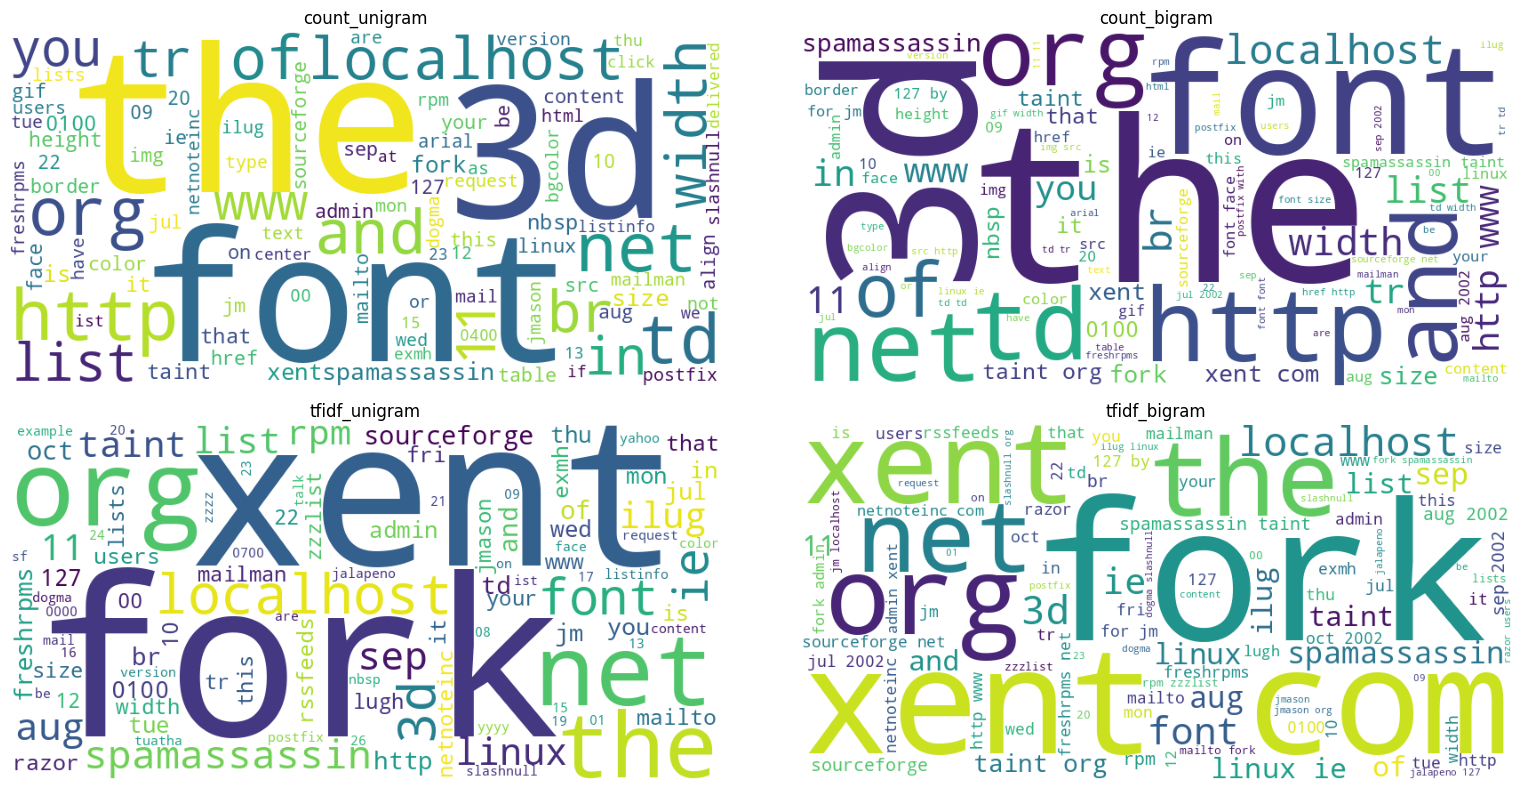

In [9]:
def get_word_cloud(name, ax):
    df2 = pd.read_csv(RAW_DATA_DIR / "spam_assassin.csv")
    vec =  VECTORIZER_CONFIGS[name]['vectorizer'](**VECTORIZER_CONFIGS[name]['params'])
    matrix = vec.fit_transform(df2['mail'])
    feature_names, means = vec.get_feature_names_out(), np.array(matrix.mean(axis=0)).flatten()

    word_freq = dict(zip(feature_names, means))
    cloud = WordCloud(width=800, height=400, 
                                background_color='white',
                                max_words=100,
                                colormap='viridis').generate_from_frequencies(word_freq)
    ax.imshow(cloud)
    ax.set_axis_off()
    ax.set_title(name)
        
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

get_word_cloud('count_unigram', axes[0, 0])
get_word_cloud('tfidf_unigram', axes[1, 0])
get_word_cloud('count_bigram', axes[0, 1])
get_word_cloud('tfidf_bigram', axes[1, 1])
plt.axis('off')
plt.tight_layout()
plt.show()

## Analiza wyników

In [10]:
preprocessing_res = pd.read_csv(OUTPUT_DATA_DIR / "experiments" / "preprocessing_study_results.csv")

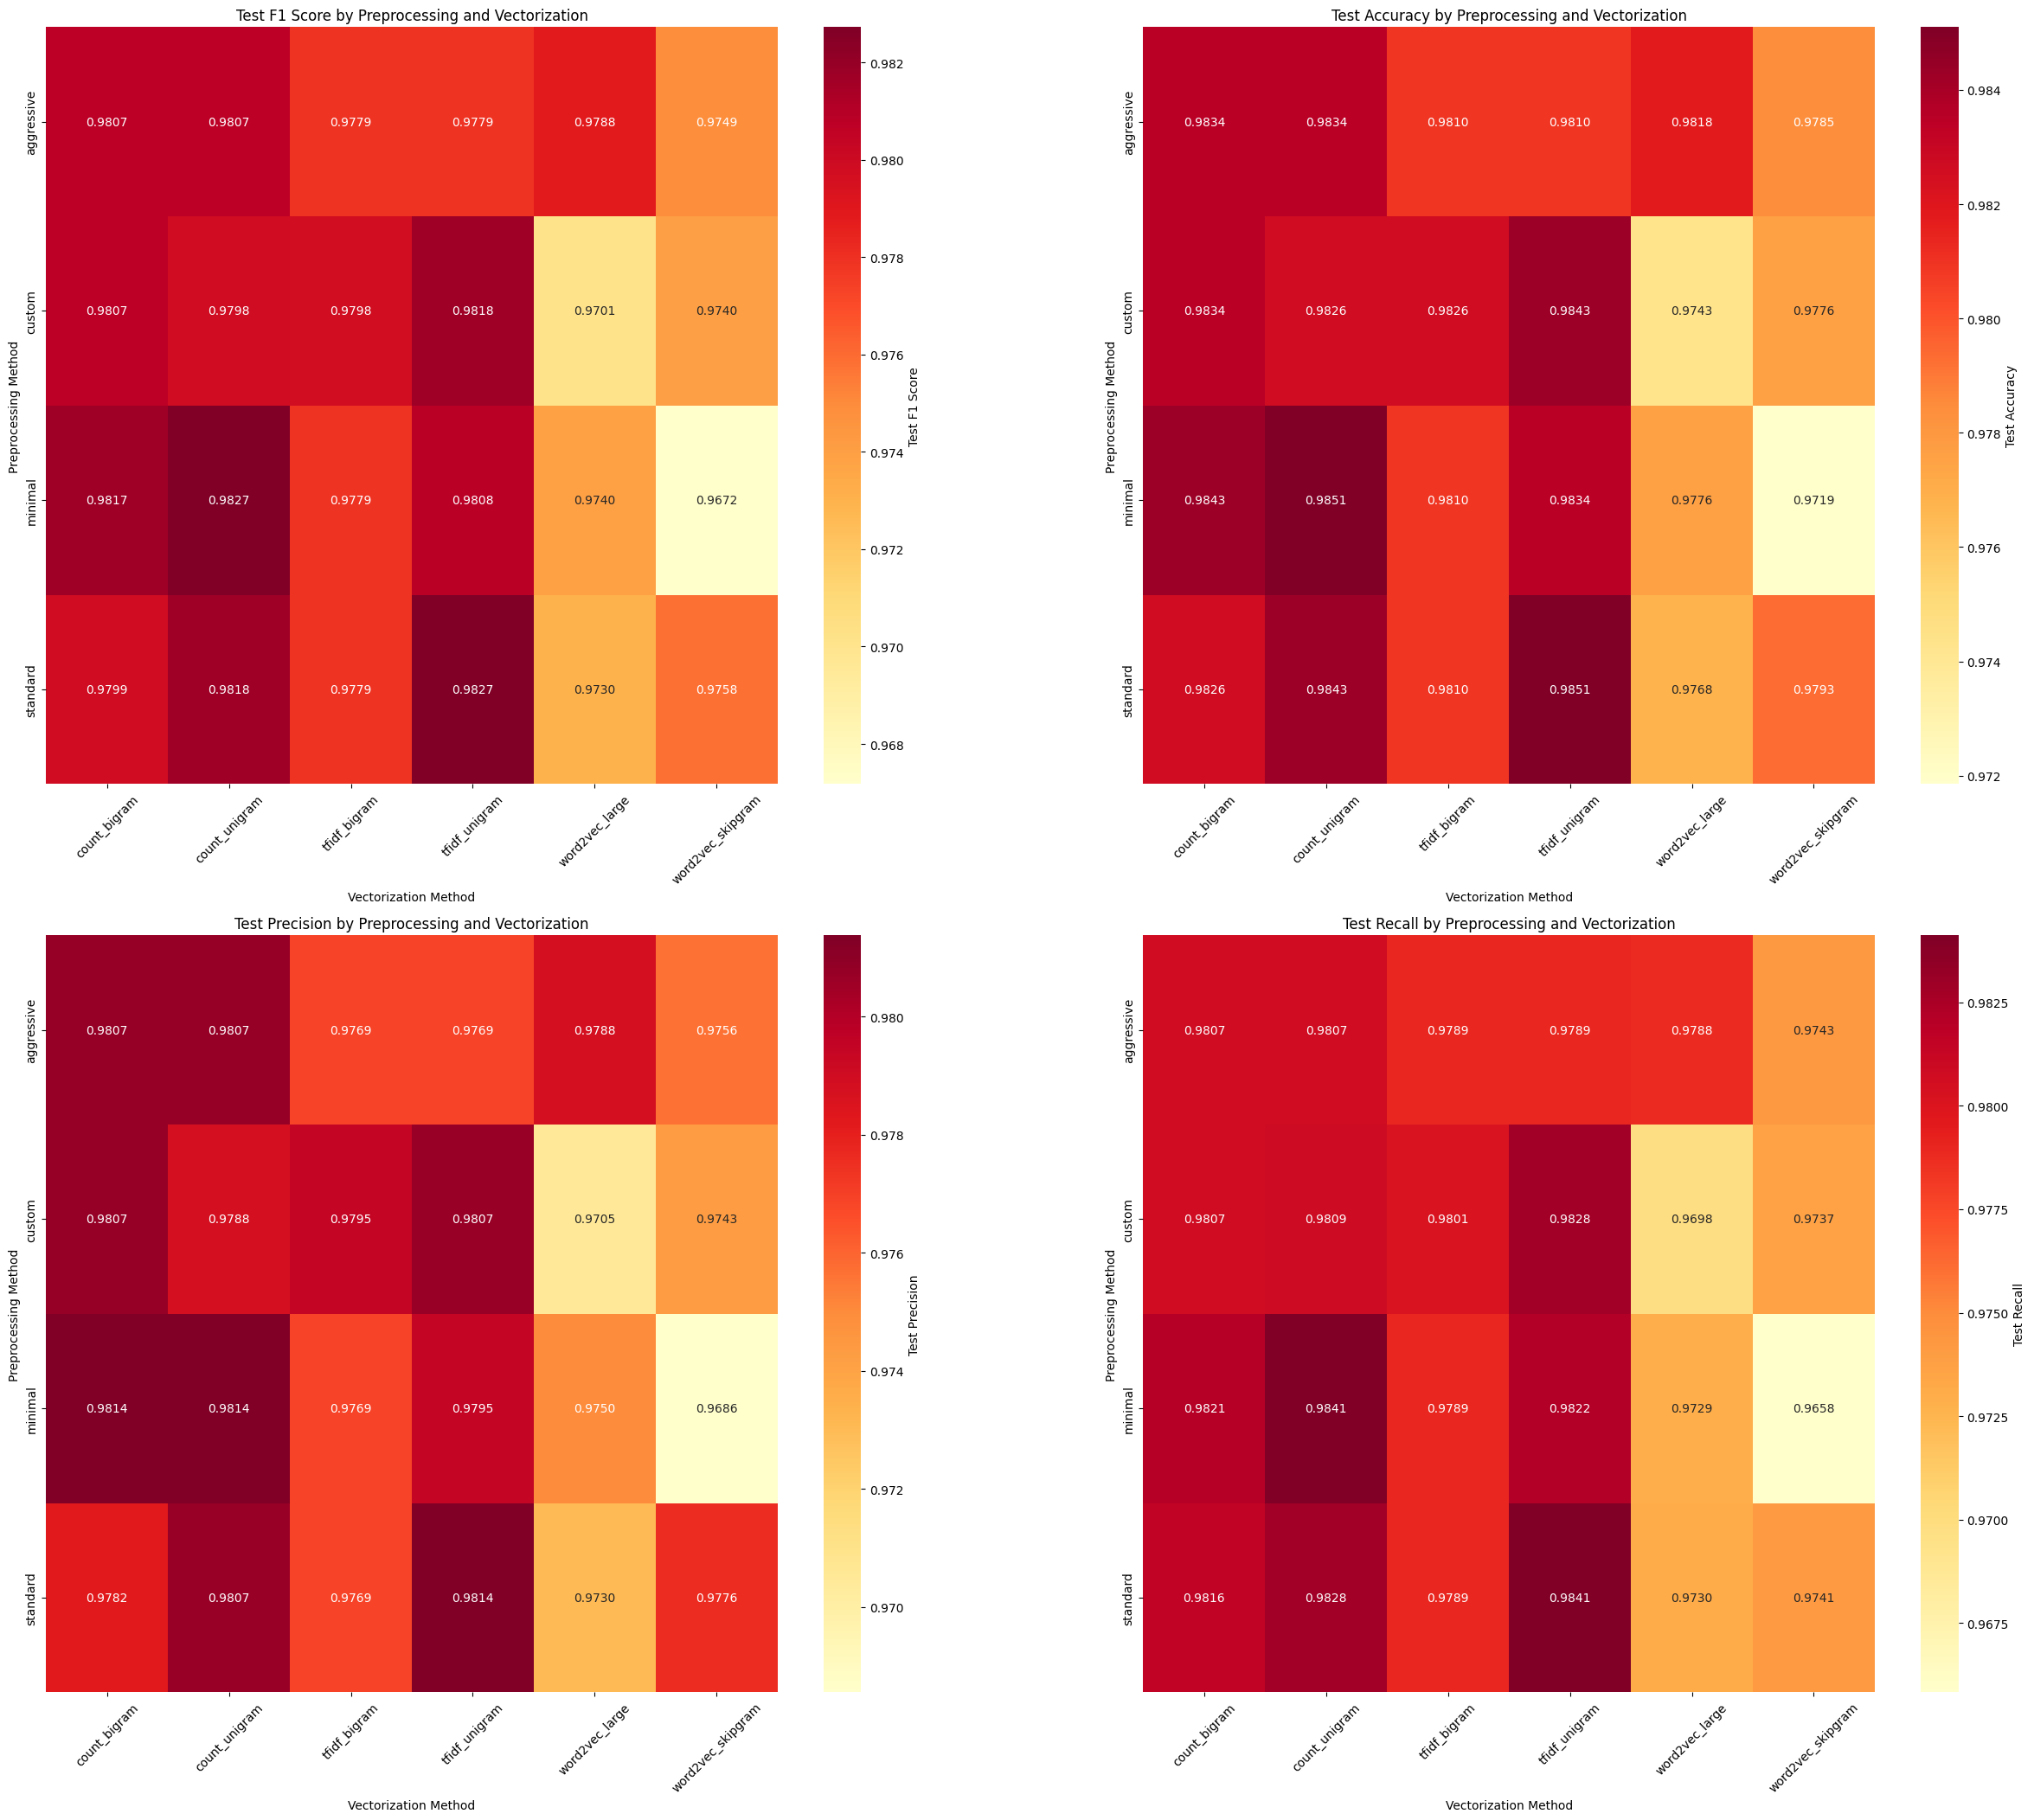

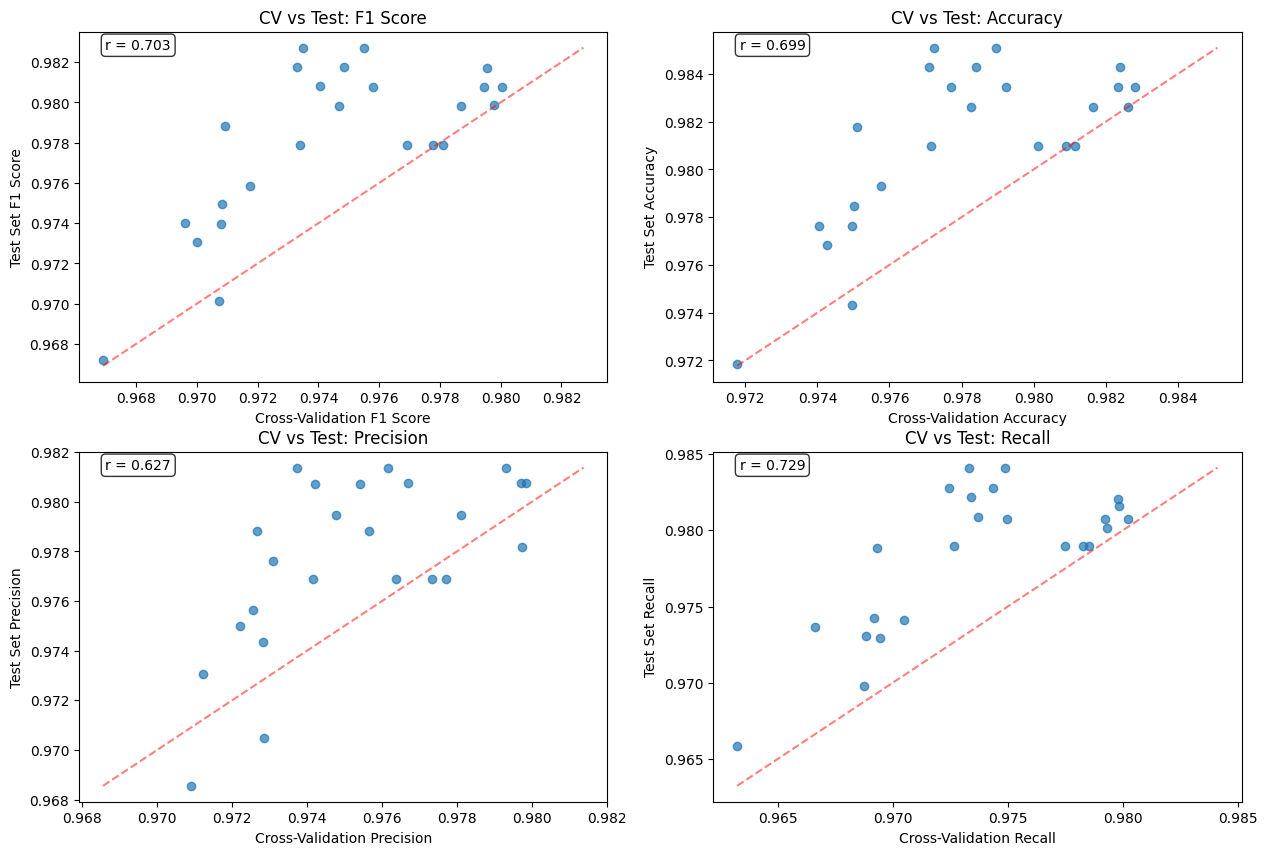

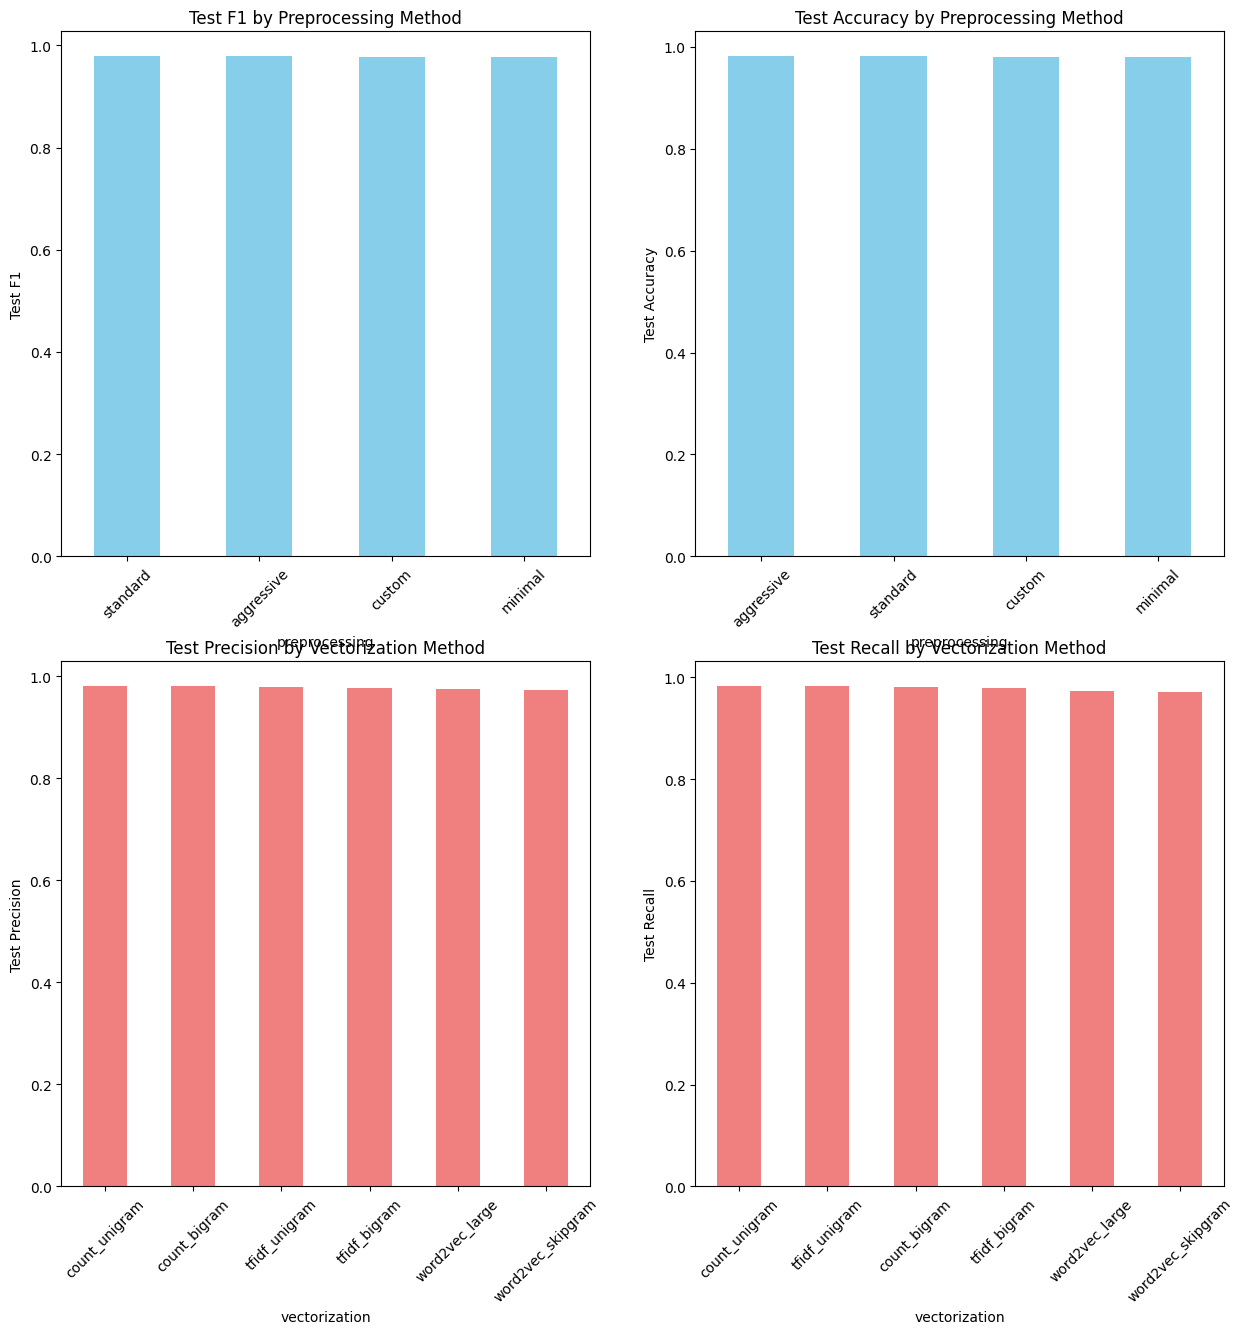

In [11]:
def create_performance_matrices(df):
    # Use test set metrics for true generalization performance
    metrics = ['test_f1_macro', 'test_accuracy', 'test_precision_macro', 'test_recall_macro']
    metric_names = ['Test F1 Score', 'Test Accuracy', 'Test Precision', 'Test Recall']
    
    fig, axes = plt.subplots(2, 2, figsize=(30, 25))
    axes = axes.flatten()
    
    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        pivot_table = df.pivot(index='preprocessing', columns='vectorization', values=metric)
        
        sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlOrRd', 
                   ax=axes[i], cbar_kws={'label': name})
        axes[i].set_title(f'{name} by Preprocessing and Vectorization')
        axes[i].set_xlabel('Vectorization Method')
        axes[i].set_ylabel('Preprocessing Method')
        axes[i].tick_params(axis='x', rotation=45)
def create_performance_comparison(df):
    # Use test set metrics
    metrics = ['test_f1_macro', 'test_accuracy', 'test_precision_macro', 'test_recall_macro']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        metric_name = metric.replace('test_', '').replace('_macro', '').title()
        
        preprocessing_means = df.groupby('preprocessing')[metric].mean().sort_values(ascending=False)
        vectorization_means = df.groupby('vectorization')[metric].mean().sort_values(ascending=False)
        
        if i < 2:
            ax = axes[i]
            preprocessing_means.plot(kind='bar', ax=ax, color='skyblue')
            ax.set_title(f'Test {metric_name} by Preprocessing Method')
            ax.set_ylabel(f'Test {metric_name}')
            ax.tick_params(axis='x', rotation=45)
        else:
            ax = axes[i]
            vectorization_means.plot(kind='bar', ax=ax, color='lightcoral')
            ax.set_title(f'Test {metric_name} by Vectorization Method')
            ax.set_ylabel(f'Test {metric_name}')
            ax.tick_params(axis='x', rotation=45)
def create_cv_vs_test_comparison(df):
    """Compare cross-validation vs test set performance"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    metrics = [('cv_test_f1_macro', 'test_f1_macro', 'F1 Score'),
               ('cv_test_accuracy', 'test_accuracy', 'Accuracy'),
               ('cv_test_precision_macro', 'test_precision_macro', 'Precision'),
               ('cv_test_recall_macro', 'test_recall_macro', 'Recall')]
    
    for i, (cv_metric, test_metric, name) in enumerate(metrics):
        ax = axes[i]
        ax.scatter(df[cv_metric], df[test_metric], alpha=0.7)
        
        # Add diagonal line for perfect correlation
        min_val = min(df[cv_metric].min(), df[test_metric].min())
        max_val = max(df[cv_metric].max(), df[test_metric].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
        
        ax.set_xlabel(f'Cross-Validation {name}')
        ax.set_ylabel(f'Test Set {name}')
        ax.set_title(f'CV vs Test: {name}')
        
        # Calculate correlation
        corr = df[cv_metric].corr(df[test_metric])
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

create_performance_matrices(preprocessing_res)
create_cv_vs_test_comparison(preprocessing_res)
create_performance_comparison(preprocessing_res)